In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../../../Data/titanic_toy.csv")
df

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0
...,...,...,...,...
886,27.0,13.0000,0,0
887,19.0,30.0000,0,1
888,NaN,23.4500,3,0
889,26.0,NaN,0,1


In [3]:
df.isnull().mean() * 100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:-1],df.iloc[:,-1], test_size=0.2, random_state=42)

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

impute_trf = ColumnTransformer(transformers=[
    ("age", SimpleImputer(strategy='constant', fill_value=99), ['Age']),
    ("fare", SimpleImputer(strategy='constant', fill_value=999), ['Fare'])
],remainder='passthrough')

In [6]:
X_train_trf = impute_trf.fit_transform(X_train)
X_test_trf = impute_trf.transform(X_test)

In [7]:
imputed_data = pd.DataFrame()
imputed_data['Age'] = df['Age']
imputed_data['Age 99'] = pd.DataFrame(X_train_trf, columns=X_train.columns)['Age']
imputed_data['Age minus_1'] = X_train['Age'].fillna(-1)


imputed_data['Fare'] = df['Fare']
imputed_data['Fare 999'] = pd.DataFrame(X_train_trf, columns=X_train.columns)['Fare']
imputed_data['Fare minus_1'] = X_train['Fare'].fillna(-1)
imputed_data

,Age,Age 99,Age minus_1,Fare,Fare 999,Fare minus_1
0,22.0,45.5,22.0,7.2500,28.5000,7.2500
1,38.0,23.0,38.0,71.2833,13.0000,71.2833
2,26.0,32.0,26.0,7.9250,7.9250,7.9250
3,35.0,26.0,35.0,53.1000,7.8542,53.1000
4,35.0,6.0,35.0,8.0500,31.2750,8.0500
...,...,...,...,...,...,...
886,27.0,NaN,NaN,13.0000,NaN,NaN
887,19.0,NaN,19.0,30.0000,NaN,30.0000
888,NaN,NaN,-1.0,23.4500,NaN,23.4500
889,26.0,NaN,NaN,NaN,NaN,NaN


# Check Distribution

<Axes: xlabel='Age', ylabel='Density'>

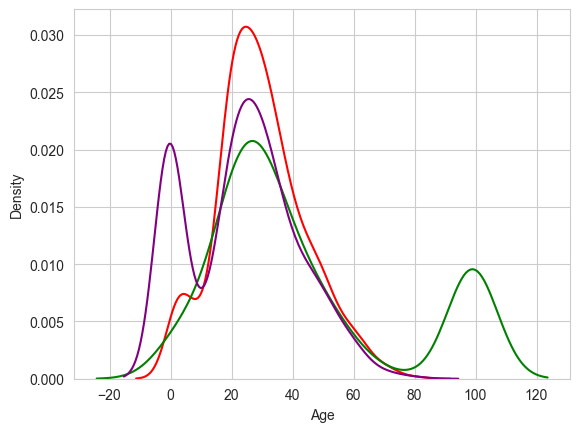

In [8]:
sns.kdeplot(data=imputed_data, x='Age',color='red')
sns.kdeplot(data=imputed_data, x='Age 99',color='green')
sns.kdeplot(data=imputed_data, x='Age minus_1',color='purple')

<Axes: xlabel='Fare', ylabel='Density'>

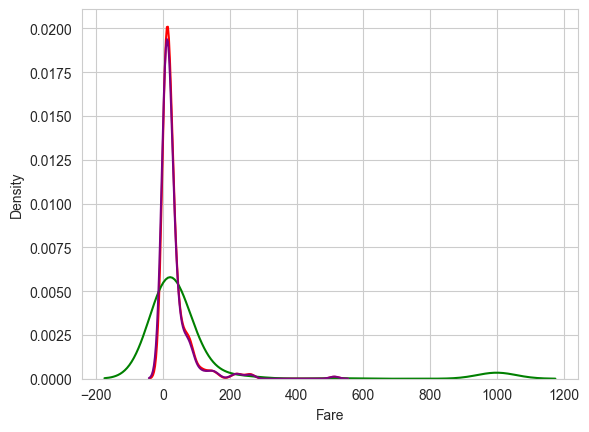

In [9]:
sns.kdeplot(data=imputed_data, x='Fare',color='red')
sns.kdeplot(data=imputed_data, x='Fare 999',color='green')
sns.kdeplot(data=imputed_data, x='Fare minus_1',color='purple')

# Check covariance

In [10]:
imputed_data.cov()

,Age,Age 99,Age minus_1,Fare,Fare 999,Fare minus_1
Age,211.019125,-6.312068,210.251707,78.071438,142.334360,69.137162
Age 99,-6.312068,932.966537,-9.266423,54.937387,-255.051165,8.409462
Age minus_1,210.251707,-9.266423,315.995504,135.785804,296.162941,124.270305
Fare,78.071438,54.937387,135.785804,2530.673077,-511.876195,2761.031435
Fare 999,142.334360,-255.051165,296.162941,-511.876195,47525.470595,-606.079031
Fare minus_1,69.137162,8.409462,124.270305,2761.031435,-606.079031,2675.239405


In [11]:
imputed_data.corr()

,Age,Age 99,Age minus_1,Fare,Fare 999,Fare minus_1
Age,1.000000,-0.014228,1.000000,0.099481,0.042645,0.085422
Age 99,-0.014228,1.000000,-0.016800,0.036791,-0.038303,0.005491
Age minus_1,1.000000,-0.016800,1.000000,0.145071,0.072625,0.135159
Fare,0.099481,0.036791,0.145071,1.000000,-0.047049,1.000000
Fare 999,0.042645,-0.038303,0.072625,-0.047049,1.000000,-0.053528
Fare minus_1,0.085422,0.005491,0.135159,1.000000,-0.053528,1.000000


# Boxplot

<Axes: >

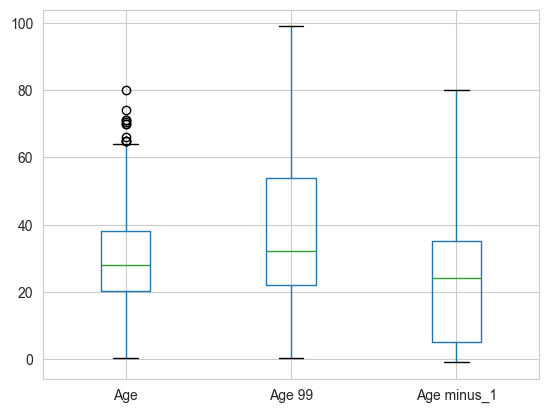

In [12]:
imputed_data.iloc[:,:3].boxplot()

<Axes: >

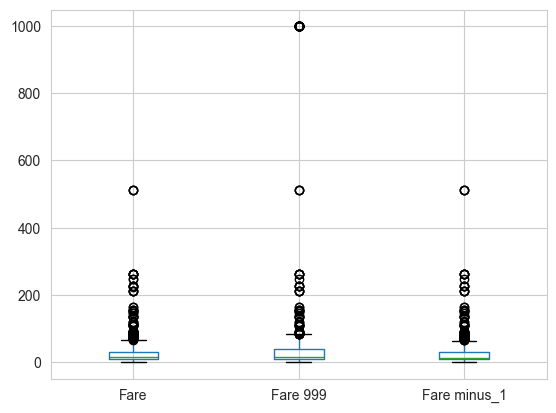

In [13]:
imputed_data.iloc[:,3:].boxplot()